In [1]:
import sys
import os
from pathlib import Path

# Robustly find the project root
current_dir = Path(os.getcwd()).resolve()
project_root = None

# Walk up until we find 'model' and 'networks' (current directory structure)
d = current_dir
for _ in range(5):
    if (d / "model").exists() and (d / "networks").exists():
        project_root = d
        break
    if d.parent == d:
        break
    d = d.parent

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    print(f"Project root found at: {project_root}")
else:
    print("Warning: Project root not found automatically. Using absolute fallback.")
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '')))


Project root found at: /Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality


# Basic Testing

In this notebook we test that the main files work well.

## Setup

In [2]:
from utils.imports import *
from model.agents import BetaAgent, BayesAgent
from model.model import Model


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# n_agents = 100
# my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

In [4]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../../networks/citation_data/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../../networks/citation_data/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


## Try with Bayes Agent

In [5]:
seed=420
my_model = Model(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True) #number_of_steps is a max amount\n",
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)
# df = pd.DataFrame(my_model.agent_histories)
# df.head(3)

100%|██████████| 10000/10000 [00:10<00:00, 953.91it/s]

steps:  10000
conclusion:  0.21839080459770116
conclusion core 0.41025641025641024


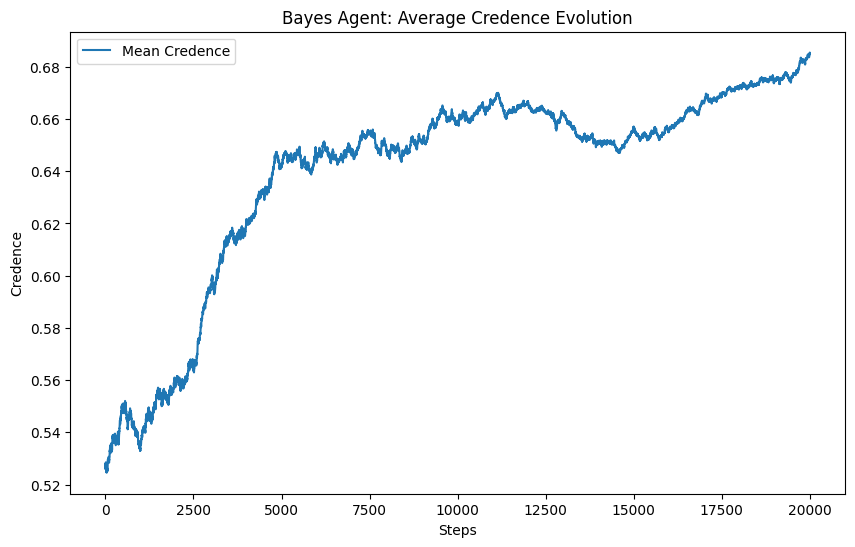

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
df_bayes = pd.DataFrame(my_model.agent_histories).T
df_bayes.head(3)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent

In [7]:
seed=420
my_model = Model(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True) #number_of_steps is a max amount\n",
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
df = pd.DataFrame(my_model.agent_histories)
df.head(3)

100%|██████████| 10000/10000 [04:06<00:00, 40.55it/s]


steps:  10000
conclusion:  0.6206896551724138


,0,1,2,3,4,5,6,7,8,9,...,19991,19992,19993,19994,19995,19996,19997,19998,19999,20000
0,"[0.5537338981042699, 0.29031764452419817]","[0.5432371696322181, 0.29031764452419817]","[0.5432371696322181, 0.3741197786757764]","[0.3932822008845857, 0.3741197786757764]","[0.3932822008845857, 0.48782641136562327]","[0.39375730680773346, 0.48782641136562327]","[0.39375730680773346, 0.3235527376297709]","[0.45352668215334485, 0.3235527376297709]","[0.45352668215334485, 0.2654516283894625]","[0.4274008557498989, 0.2654516283894625]",...,"[0.5002185255453228, 0.49886988383496017]","[0.5002185255453228, 0.49957994669717276]","[0.49633092783831667, 0.49957994669717276]","[0.49633092783831667, 0.5000824292223105]","[0.4988473383143224, 0.5000824292223105]","[0.4988473383143224, 0.5003093612065366]","[0.4973544782431765, 0.5003093612065366]","[0.4973544782431765, 0.498853975850966]","[0.5011423091057242, 0.498853975850966]","[0.5011423091057242, 0.4987973858025562]"
1,"[0.06973409038777925, 0.004968288658220723]","[0.11707411298595662, 0.004968288658220723]","[0.11707411298595662, 0.3422564652617926]","[0.10392334671644167, 0.3422564652617926]","[0.10392334671644167, 0.4628461873692075]","[0.32225022987715846, 0.4628461873692075]","[0.32225022987715846, 0.43509803837192523]","[0.4348281616887091, 0.43509803837192523]","[0.4348281616887091, 0.2862585385670291]","[0.4921905267615694, 0.2862585385670291]",...,"[0.4995182723248917, 0.49892337383583213]","[0.4995182723248917, 0.4999655399363521]","[0.4975858709926213, 0.4999655399363521]","[0.4975858709926213, 0.5001931856659804]","[0.4963805622440465, 0.5001931856659804]","[0.4963805622440465, 0.5028230205276755]","[0.4994817832379457, 0.5028230205276755]","[0.4994817832379457, 0.5021736863223836]","[0.5010000146135938, 0.5021736863223836]","[0.5010000146135938, 0.500548944913949]"
2,"[0.9870132454391944, 0.9991221232539964]","[0.721919201962232, 0.9991221232539964]","[0.721919201962232, 0.7413177105695156]","[0.4531272904709232, 0.7413177105695156]","[0.4531272904709232, 0.5802091788388635]","[0.6444903467735125, 0.5802091788388635]","[0.6444903467735125, 0.5332091016591598]","[0.5862326425882771, 0.5332091016591598]","[0.5862326425882771, 0.525194161064315]","[0.5709622233740508, 0.525194161064315]",...,"[0.4996585477180985, 0.5008450489394763]","[0.4996585477180985, 0.5003882713531068]","[0.4999584486437072, 0.5003882713531068]","[0.4999584486437072, 0.5020207932634365]","[0.4995405372036385, 0.5020207932634365]","[0.4995405372036385, 0.500880469352436]","[0.5010707186916343, 0.500880469352436]","[0.5010707186916343, 0.5018066373811876]","[0.4975973664259934, 0.5018066373811876]","[0.4975973664259934, 0.5008230633502141]"


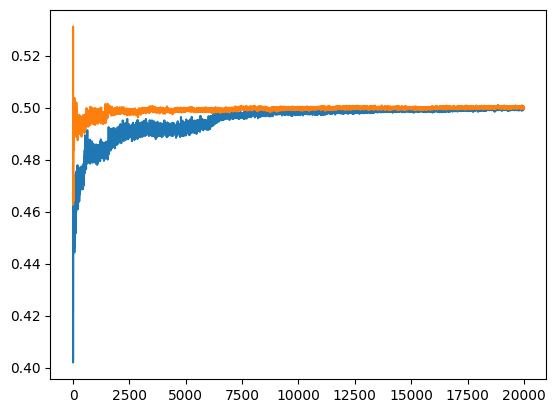

In [8]:
#Extract the first coordinate (x) for each pair and calculate column-wise mean
x_means = df.map(lambda pair: pair[0]).mean()
y_means = df.map(lambda pair: pair[1]).mean()
plt.plot(x_means)
plt.plot(y_means)

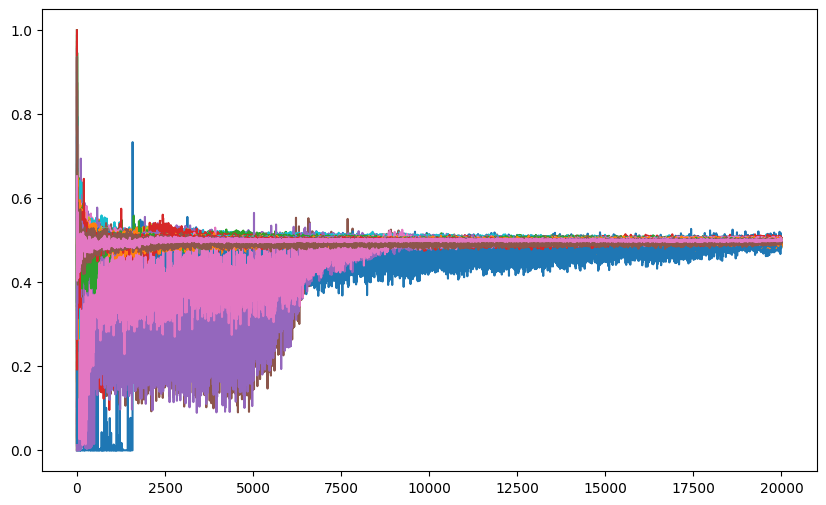

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row
plt.figure(figsize=(10, 6))
for row_idx in range(x_values.shape[0]):
    plt.plot(x_values.columns, x_values.iloc[row_idx, :], label=f'Row {row_idx+1}' if row_idx < 5 else None)